In [ ]:
import kagglehub
path = kagglehub.dataset_download("gillesokhin/nutrition5k-dataset")

Using Colab cache for faster access to the 'nutrition5k-dataset' dataset.


In [ ]:
# Cell 0: Kaggle environment setup (run once)
!pip install -q timm albumentations

# standard imports
import os
import random
import numpy as np
import pandas as pd
from PIL import Image
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.metrics import average_precision_score
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T
import timm
import albumentations as A
from albumentations.pytorch import ToTensorV2

# device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


In [ ]:
# Cell 2: Define dataset paths and load CSV
# `path` variable is from the kagglehub.dataset_download in cell 1
ROOT = path
OVERHEAD_DIR = os.path.join(ROOT, "imagery", "realsense_overhead")
CSV_PATH = os.path.join(ROOT, "dish_nutrition_values.csv")

df = pd.read_csv(CSV_PATH)
print("CSV columns:", df.columns.tolist())
print("Example rows:")
display(df.head(3))

CSV columns: ['dish_id', 'calories', 'mass', 'fat', 'carb', 'protein']
Example rows:


,dish_id,calories,mass,fat,carb,protein
0,dish_1561662216,300.794281,193.0,12.387489,28.218290,18.633970
1,dish_1562688426,137.569992,88.0,8.256000,5.190000,10.297000
2,dish_1561662054,419.438782,292.0,23.838249,26.351543,25.910593


In [ ]:
# Cell 3
# CSV dish_id includes 'dish_' prefix (as you confirmed)
def build_paths(row):
    dish = row['dish_id']  # e.g. 'dish_1561662216'
    folder = os.path.join(OVERHEAD_DIR, dish)
    rgb = os.path.join(folder, "rgb.png")
    depth_color = os.path.join(folder, "depth_color.png")
    return rgb, depth_color

df['rgb_path'], df['depth_color_path'] = zip(*df.apply(build_paths, axis=1))

# Filter rows where both files exist
mask = df['rgb_path'].apply(os.path.exists) & df['depth_color_path'].apply(os.path.exists)
missing = (~mask).sum()
print(f"Found {mask.sum()} dish folders with both rgb.png and depth_color.png ({missing} missing).")
df = df[mask].reset_index(drop=True)
print("Final dataset size:", len(df))
df.head(3)

Found 3243 dish folders with both rgb.png and depth_color.png (1525 missing).
Final dataset size: 3243


,dish_id,calories,mass,fat,carb,protein,rgb_path,depth_color_path
0,dish_1561662216,300.794281,193.0,12.387489,28.218290,18.633970,/kaggle/input/nutrition5k-dataset/imagery/real...,/kaggle/input/nutrition5k-dataset/imagery/real...
1,dish_1561662054,419.438782,292.0,23.838249,26.351543,25.910593,/kaggle/input/nutrition5k-dataset/imagery/real...,/kaggle/input/nutrition5k-dataset/imagery/real...
2,dish_1562008979,382.936646,290.0,22.224644,10.173570,35.345387,/kaggle/input/nutrition5k-dataset/imagery/real...,/kaggle/input/nutrition5k-dataset/imagery/real...


In [ ]:
# Cell 4
nutrients = ["calories", "mass", "fat", "carb", "protein"]
# create bin columns e.g. calories_bin with labels 0,1,2 (3 quantile bins)
for col in nutrients:
    # If there are any NaNs, drop them first (or fill as you prefer)
    df = df[df[col].notna()]
    df[col + "_bin"] = pd.qcut(df[col], 3, labels=[0,1,2]).astype(int)

label_cols = [c + "_bin" for c in nutrients]   # e.g. ['calories_bin', ...]
print("Label columns:", label_cols)
display(df[[ 'dish_id'] + nutrients + label_cols].head(3))


Label columns: ['calories_bin', 'mass_bin', 'fat_bin', 'carb_bin', 'protein_bin']


,dish_id,calories,mass,fat,carb,protein,calories_bin,mass_bin,fat_bin,carb_bin,protein_bin
0,dish_1561662216,300.794281,193.0,12.387489,28.218290,18.633970,1,1,1,2,1
1,dish_1561662054,419.438782,292.0,23.838249,26.351543,25.910593,2,2,2,2,2
2,dish_1562008979,382.936646,290.0,22.224644,10.173570,35.345387,2,2,2,1,2


In [ ]:
# Cell 5
train_df, val_df = train_test_split(df, test_size=0.15, random_state=42)
train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
print("Train:", len(train_df), "Val:", len(val_df))

Train: 2756 Val: 487


In [ ]:
# Cell 6
class Nutrition5kDataset(Dataset):
    def __init__(self, df, label_cols, transforms=None):
        self.df = df
        self.label_cols = label_cols
        self.transforms = transforms

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        rgb = np.array(Image.open(row['rgb_path']).convert("RGB"))
        depth_color = np.array(Image.open(row['depth_color_path']).convert("RGB"))

        # Both are H x W x 3 arrays. Pass them to albumentations as two images.
        if self.transforms:
            augmented = self.transforms(image=rgb, depth=depth_color)
            rgb_t = augmented['image']
            depth_t = augmented['depth']
            # Correct: Concatenate along the channel dimension (dim=0 for CHW tensors)
            stacked_tensor = torch.cat([rgb_t, depth_t], dim=0)
        else:
            # if no transforms, convert to tensor-like numpy arrays and transpose manually
            rgb_t = rgb.astype(np.float32) / 255.0
            depth_t = depth_color.astype(np.float32) / 255.0
            # Concatenate HWC numpy arrays, then transpose to CHW tensor
            stacked_np = np.concatenate([rgb_t, depth_t], axis=2)
            stacked_tensor = torch.from_numpy(np.transpose(stacked_np, (2,0,1)))

        labels = torch.tensor(row[self.label_cols].values.astype(np.int64))
        return stacked_tensor, labels

In [ ]:
# Cell 7
train_transforms = A.Compose([
    A.Resize(320, 320),
    A.HorizontalFlip(p=0.5),
    A.ShiftScaleRotate(shift_limit=0.03, scale_limit=0.08, rotate_limit=15, p=0.4),
    A.RandomBrightnessContrast(brightness_limit=0.15, contrast_limit=0.15, p=0.4),
    A.Normalize(mean=(0.485,0.456,0.406), std=(0.229,0.224,0.225)),
    ToTensorV2()
], additional_targets={'depth': 'image'})

val_transforms = A.Compose([
    A.Resize(320, 320),
    A.Normalize(mean=(0.485,0.456,0.406), std=(0.229,0.224,0.225)),
    ToTensorV2()
], additional_targets={'depth': 'image'})

train_ds = Nutrition5kDataset(train_df, label_cols, transforms=train_transforms)
val_ds   = Nutrition5kDataset(val_df, label_cols, transforms=val_transforms)

BATCH_SIZE = 16   # change depending on GPU memory
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

# quick shape sanity check
x, y = next(iter(train_loader))
print("batch images shape:", x.shape)   # should be (B, 6, H, W)
print("batch labels shape:", y.shape)   # (B, num_nutrients)

/usr/local/lib/python3.12/dist-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)


batch images shape: torch.Size([16, 6, 320, 320])
batch labels shape: torch.Size([16, 5])


In [ ]:
num_nutrients = len(nutrients)       # 5 in your CSV
num_bins = 3
num_outputs = num_nutrients * num_bins  # e.g. 5*3 = 15

model_name = "efficientnet_b3" # Updated to EfficientNet B3
model = timm.create_model(model_name, pretrained=True, in_chans=6, num_classes=num_outputs)
model = model.to(device)
print(model)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


EfficientNet(
  (conv_stem): Conv2d(6, 40, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
  (bn1): BatchNormAct2d(
    40, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True
    (drop): Identity()
    (act): SiLU(inplace=True)
  )
  (blocks): Sequential(
    (0): Sequential(
      (0): DepthwiseSeparableConv(
        (conv_dw): Conv2d(40, 40, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=40, bias=False)
        (bn1): BatchNormAct2d(
          40, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True
          (drop): Identity()
          (act): SiLU(inplace=True)
        )
        (aa): Identity()
        (se): SqueezeExcite(
          (conv_reduce): Conv2d(40, 10, kernel_size=(1, 1), stride=(1, 1))
          (act1): SiLU(inplace=True)
          (conv_expand): Conv2d(10, 40, kernel_size=(1, 1), stride=(1, 1))
          (gate): Sigmoid()
        )
        (conv_pw): Conv2d(40, 24, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (b

In [ ]:
# Cell 9
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=2e-4, weight_decay=1e-5)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=2)

In [ ]:
# Cell 10
def train_one_epoch(model, loader, optimizer, device):
    model.train()
    total_loss = 0.0
    pbar = tqdm(loader, desc="train", leave=False)
    for imgs, labels in pbar:
        imgs = imgs.to(device)
        labels = labels.to(device)   # shape B x num_nutrients

        optimizer.zero_grad()
        logits = model(imgs)         # shape B x (num_nutrients*num_bins)
        # reshape to (B, num_nutrients, num_bins)
        logits_r = logits.view(-1, num_nutrients, num_bins)

        # compute sum of CE across nutrients
        loss = sum(criterion(logits_r[:, i], labels[:, i]) for i in range(num_nutrients))
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * imgs.size(0)
        pbar.set_postfix(loss=loss.item())
    return total_loss / len(loader.dataset)

def compute_map(model, loader, device):
    model.eval()
    all_probs = []
    all_onehot = []
    with torch.no_grad():
        for imgs, labels in loader:
            imgs = imgs.to(device)
            logits = model(imgs)   # B x (N*num_bins)
            # reshape and softmax per nutrient
            logits_r = logits.view(-1, num_nutrients, num_bins).cpu().numpy()
            probs = np.softmax(logits_r, axis=2) if hasattr(np, 'softmax') else np.exp(logits_r)/np.sum(np.exp(logits_r), axis=2, keepdims=True)
            # probs shape B x N x num_bins

            # flatten probs to B x (N*num_bins)
            B = probs.shape[0]
            probs_flat = probs.reshape(B, -1)
            all_probs.append(probs_flat)

            # build one-hot true labels per bin
            lab = labels.numpy()  # B x N
            onehot = np.zeros_like(probs_flat, dtype=np.int32)  # B x (N*num_bins)
            for i in range(num_nutrients):
                # for nutrient i, set column i*num_bins + true_bin = 1
                idx = lab[:, i].astype(int)
                cols = i * num_bins + idx
                onehot[np.arange(B), cols] = 1
            all_onehot.append(onehot)

    y_score = np.vstack(all_probs)
    y_true = np.vstack(all_onehot)

    # compute AP per flattened class (i.e., each bin for each nutrient)
    ap_list = []
    for c in range(y_true.shape[1]):
        # skip classes with no positive examples in val set
        if y_true[:, c].sum() == 0:
            ap_list.append(np.nan)
            continue
        try:
            ap = average_precision_score(y_true[:, c], y_score[:, c])
            ap_list.append(ap)
        except ValueError:
            ap_list.append(np.nan)

    ap_array = np.array(ap_list, dtype=np.float32)
    mean_ap = np.nanmean(ap_array)
    return mean_ap, ap_array.reshape(num_nutrients, num_bins)

In [ ]:
from tqdm.autonotebook import tqdm

# Cell 11
EPOCHS = 8
best_map = 0.0

for epoch in range(1, EPOCHS+1):
    train_loss = train_one_epoch(model, train_loader, optimizer, device)
    val_map, ap_table = compute_map(model, val_loader, device)
    scheduler.step(val_map)

    print(f"Epoch {epoch}/{EPOCHS} — Train loss: {train_loss:.4f} | Val mAP: {val_map:.4f}")
    # print per-nutrient AP (3 bins each)
    for i, nutrient in enumerate(nutrients):
        print(f"  {nutrient}: AP per bin = {ap_table[i].round(4).tolist()}")
    # save best
    if val_map > best_map:
        best_map = val_map
        torch.save(model.state_dict(), "best_effnet6ch_nutrition5k.pth")
        print("  Saved best model with mAP:", best_map)

train:   0%|          | 0/173 [00:00<?, ?it/s]

Epoch 1/8 — Train loss: 4.4032 | Val mAP: 0.7279
  calories: AP per bin = [0.8410999774932861, 0.5047000050544739, 0.8367999792098999]
  mass: AP per bin = [0.887499988079071, 0.6478000283241272, 0.9065999984741211]
  fat: AP per bin = [0.7929999828338623, 0.5002999901771545, 0.7979999780654907]
  carb: AP per bin = [0.6870999932289124, 0.5019000172615051, 0.7714999914169312]
  protein: AP per bin = [0.8761000037193298, 0.595300018787384, 0.7706999778747559]
  Saved best model with mAP: 0.7278869


train:   0%|          | 0/173 [00:00<?, ?it/s]

Epoch 2/8 — Train loss: 2.9041 | Val mAP: 0.7900
  calories: AP per bin = [0.8812000155448914, 0.5911999940872192, 0.8708000183105469]
  mass: AP per bin = [0.916700005531311, 0.7271999716758728, 0.921500027179718]
  fat: AP per bin = [0.8607000112533569, 0.6262999773025513, 0.8499000072479248]
  carb: AP per bin = [0.7825000286102295, 0.5684999823570251, 0.7946000099182129]
  protein: AP per bin = [0.919700026512146, 0.6916000247001648, 0.8474000096321106]
  Saved best model with mAP: 0.7899873


train:   0%|          | 0/173 [00:00<?, ?it/s]

...

Epoch 6/8 — Train loss: 0.9466 | Val mAP: 0.8284
  calories: AP per bin = [0.9114999771118164, 0.6632999777793884, 0.8913000226020813]
  mass: AP per bin = [0.9264000058174133, 0.7099999785423279, 0.921999990940094]
  fat: AP per bin = [0.9107999801635742, 0.6754000186920166, 0.8844000101089478]
  carb: AP per bin = [0.824400007724762, 0.6628999710083008, 0.8312000036239624]
  protein: AP per bin = [0.9545999765396118, 0.7893999814987183, 0.8684999942779541]
  Saved best model with mAP: 0.8283924


train:   0%|          | 0/173 [00:00<?, ?it/s]

Epoch 7/8 — Train loss: 0.7286 | Val mAP: 0.8449
  calories: AP per bin = [0.9180999994277954, 0.6694999933242798, 0.909500002861023]
  mass: AP per bin = [0.9247000217437744, 0.739300012588501, 0.9207000136375427]
  fat: AP per bin = [0.925599992275238, 0.7027999758720398, 0.8992999792098999]
  carb: AP per bin = [0.8525000214576721, 0.6848999857902527, 0.8546000123023987]
  protein: AP per bin = [0.9567000269889832, 0.8163999915122986, 0.8984000086784363]
  Saved best model with mAP: 0.8448587


train:   0%|          | 0/173 [00:00<?, ?it/s]

Epoch 8/8 — Train loss: 0.5953 | Val mAP: 0.8426
  calories: AP per bin = [0.9132999777793884, 0.6931999921798706, 0.9088000059127808]
  mass: AP per bin = [0.9186000227928162, 0.6865000128746033, 0.9223999977111816]
  fat: AP per bin = [0.9366000294685364, 0.7523000240325928, 0.917900025844574]
  carb: AP per bin = [0.8319000005722046, 0.6764000058174133, 0.8499000072479248]
  protein: AP per bin = [0.9441999793052673, 0.785099983215332, 0.9025999903678894]


In [ ]:
# Cell 12
model.load_state_dict(torch.load("best_effnet6ch_nutrition5k.pth", map_location=device))
model.eval()

imgs, labels = next(iter(val_loader))
with torch.no_grad():
    logits = model(imgs.to(device))
    logits_r = logits.view(-1, num_nutrients, num_bins)
    probs = torch.softmax(logits_r, dim=2).cpu().numpy()   # B x N x bins

# show first sample predicted bin and probabilities
sample_idx = 0
pred_bins = probs[sample_idx].argmax(axis=1)
print("True bins:", labels[sample_idx].numpy())
print("Pred bins:", pred_bins)
print("Pred probs (per nutrient):")
for i, nutrient in enumerate(nutrients):
    print(f"  {nutrient}: {probs[sample_idx, i].round(4)}")


True bins: [2 2 2 1 2]
Pred bins: [2 2 2 1 2]
Pred probs (per nutrient):
  calories: [3.000e-04 2.200e-03 9.975e-01]
  mass: [0.0012 0.002  0.9968]
  fat: [0.     0.0655 0.9345]
  carb: [0.1726 0.6725 0.1548]
  protein: [0.0024 0.0018 0.9958]


In [ ]:
all_true_bins = []
all_pred_probs = []

model.eval()
with torch.no_grad():
    for imgs, labels in val_loader:
        imgs = imgs.to(device)
        logits = model(imgs)
        logits_r = logits.view(-1, num_nutrients, num_bins)  # B x N x bins
        probs = torch.softmax(logits_r, dim=2).cpu().numpy()

        # convert true labels to bins
        # assuming labels are already discretized to bins; if not, discretize here
        true_bins = labels.numpy().astype(int)

        all_true_bins.append(true_bins)
        all_pred_probs.append(probs)

all_true_bins = np.vstack(all_true_bins)      # shape: val_size x N
all_pred_probs = np.vstack(all_pred_probs)    # shape: val_size x N x bins


In [ ]:
from sklearn.metrics import average_precision_score

mAP_per_nutrient = []

for i in range(num_nutrients):
    # One-hot encode the true labels
    true_one_hot = np.eye(num_bins)[all_true_bins[:, i]]  # val_size x bins

    # Compute average precision for this nutrient
    ap = average_precision_score(true_one_hot, all_pred_probs[:, i, :], average='macro')
    mAP_per_nutrient.append(ap)

# Print results
for i, nutrient in enumerate(nutrients):
    print(f"{nutrient} mAP: {mAP_per_nutrient[i]:.4f}")

print(f"Mean mAP across all nutrients: {np.mean(mAP_per_nutrient):.4f}")

calories mAP: 0.8324
mass mAP: 0.8615
fat mAP: 0.8426
carb mAP: 0.7973
protein mAP: 0.8905
Mean mAP across all nutrients: 0.8449


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
def plot_sample_prediction(sample_idx, nutrients, true_bins, pred_probs):
    """
    sample_idx : int, index of the sample to plot
    nutrients : list of nutrient names
    true_bins : array, shape (num_samples, num_nutrients)
    pred_probs : array, shape (num_samples, num_nutrients, num_bins)
    """
    num_nutrients = len(nutrients)
    num_bins = pred_probs.shape[2]

    fig, axes = plt.subplots(1, num_nutrients, figsize=(4*num_nutrients, 4))

    for i, ax in enumerate(axes):
        bins = np.arange(num_bins)
        ax.bar(bins, pred_probs[sample_idx, i], color='skyblue', alpha=0.7, label='Predicted Prob')
        ax.axvline(true_bins[sample_idx, i], color='red', linestyle='--', label='True Bin')
        ax.set_title(nutrients[i])
        ax.set_xlabel("Bins")
        ax.set_ylabel("Probability")
        ax.set_ylim(0, 1)
        ax.legend()

    plt.tight_layout()
    plt.show()

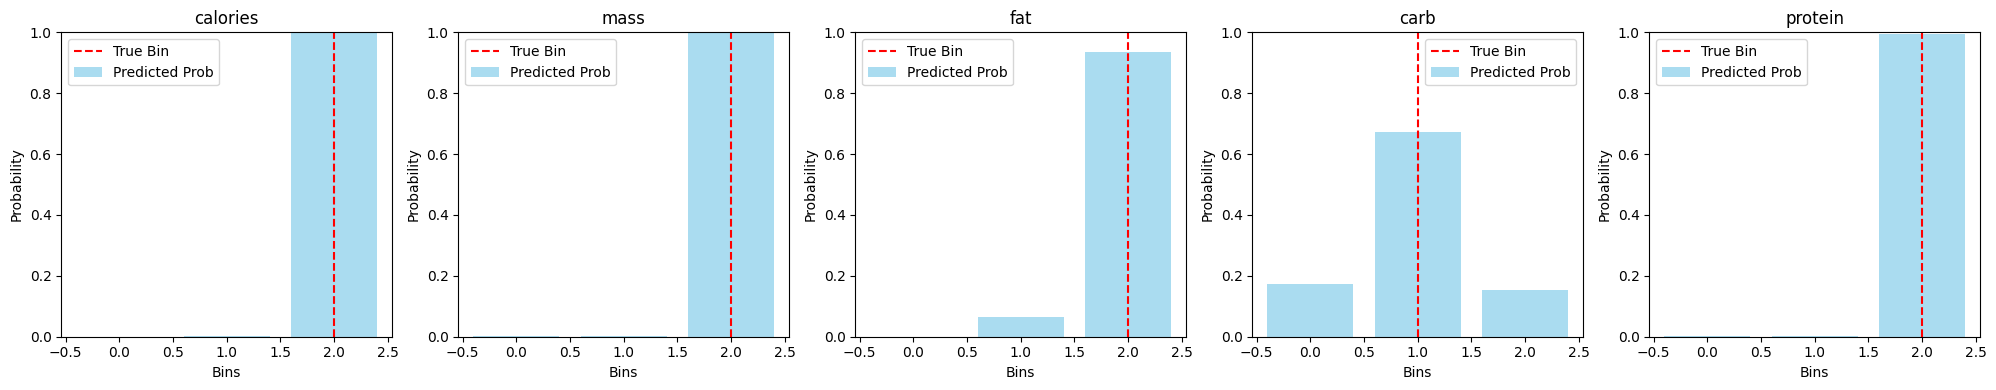

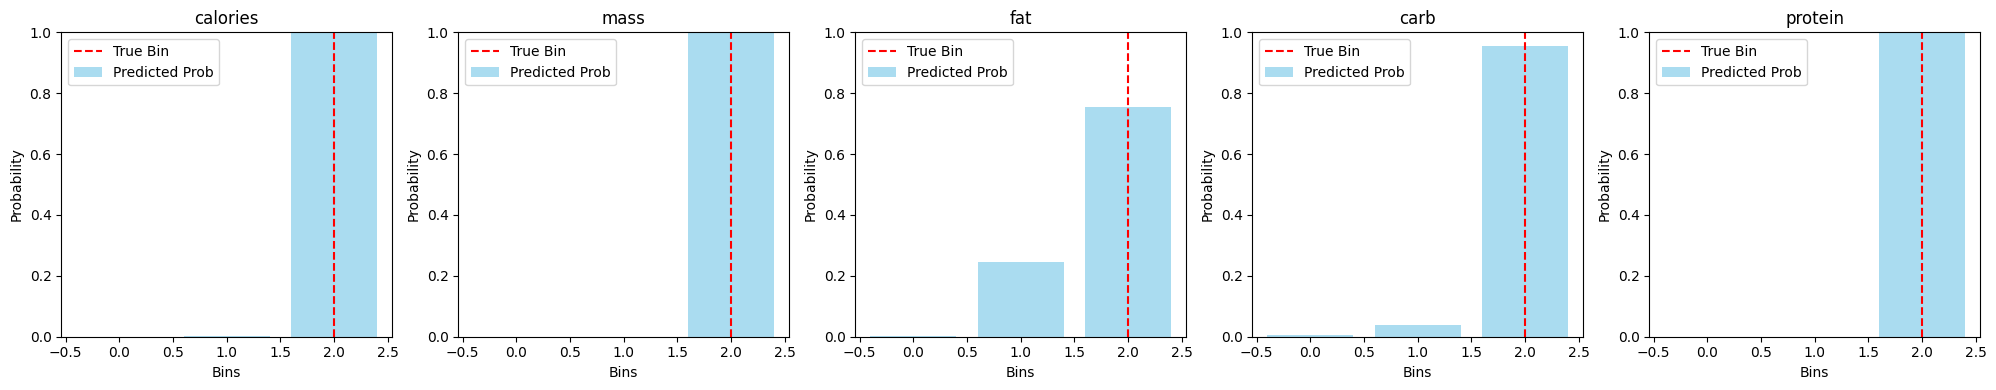

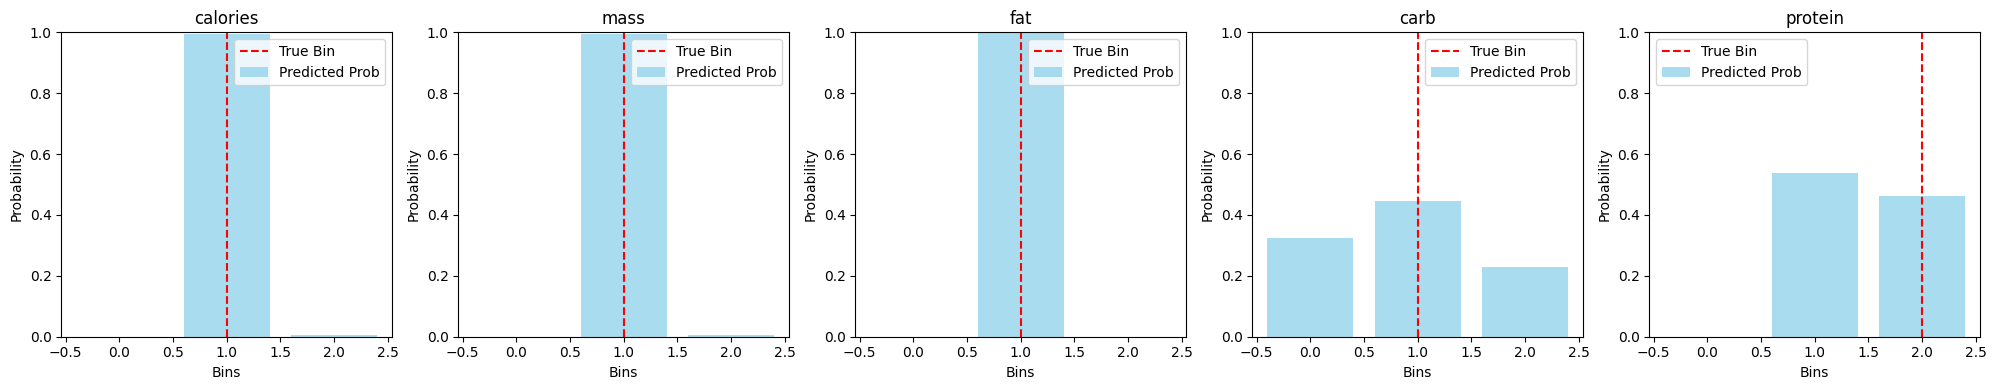

In [ ]:
# Plot first 3 validation samples
for idx in range(3):
    plot_sample_prediction(idx, nutrients, all_true_bins, all_pred_probs)